In [1]:
!apt install -y tesseract-ocr
!pip install pymupdf pytesseract opencv-python pillow numpy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 65.1 MB/s eta 0:00:00


In [2]:
import fitz  # PyMuPDF - for opening PDFs
import cv2   # OpenCV - for image processing
import pytesseract  # Tesseract OCR - for reading text
import numpy as np  # NumPy - for working with image data
from PIL import Image  # Pillow - for displaying images

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
from google.colab import files

print("Click the button below to upload your pharmaceutical SDF (PDF file):")
uploaded = files.upload()

# Get the filename of the uploaded file
pdf_path = list(uploaded.keys())[0]
print(f"\nUploaded: {pdf_path}")

# Open the PDF document
doc = fitz.open(pdf_path)
print(f"Document has {len(doc)} page(s)")

Click the button below to upload your pharmaceutical SDF (PDF file):


Saving pharmaceutical-sdf-page2-animal-origin.pdf to pharmaceutical-sdf-page2-animal-origin.pdf

Uploaded: pharmaceutical-sdf-page2-animal-origin.pdf
Document has 1 page(s)


In [5]:
# Get the first page of our PDF
page = doc[0]

# Try to extract text the normal way
text = page.get_text("text")

print("Attempting direct text extraction (without OCR):")
print("-" * 50)
if text.strip():
    print(text[:500])  # Show first 500 characters
else:
    print("[EMPTY] - No text found! This PDF is a scanned image.")
    print("This is why we need OCR - to 'read' the picture of text!")


Attempting direct text extraction (without OCR):
--------------------------------------------------
[EMPTY] - No text found! This PDF is a scanned image.
This is why we need OCR - to 'read' the picture of text!


Here's your pharmaceutical document as an image:


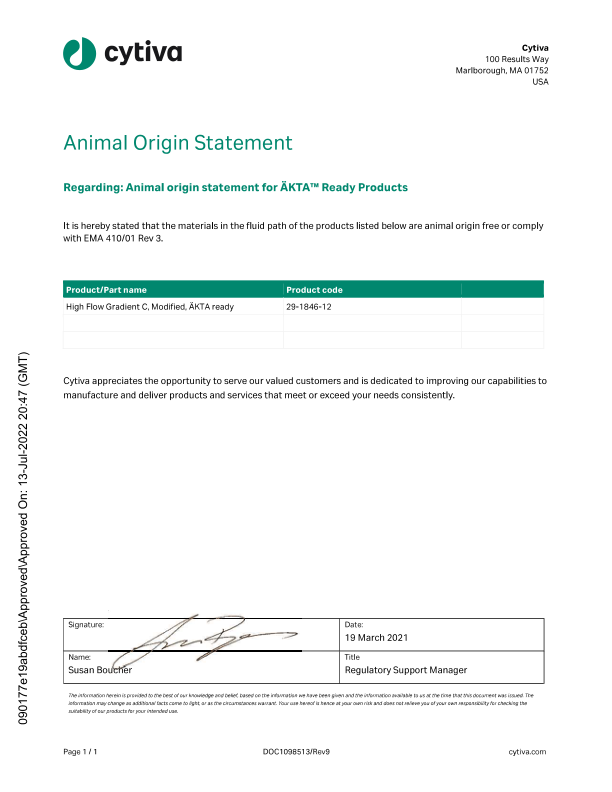

In [6]:
# Convert the page to pixels (an image)
pix = page.get_pixmap()

# Convert to a format we can work with
img = np.array(Image.frombytes("RGB", [pix.width, pix.height], pix.samples))

# Display the original image
print("Here's your pharmaceutical document as an image:")
display(Image.fromarray(img))

Grayscale version (color removed):


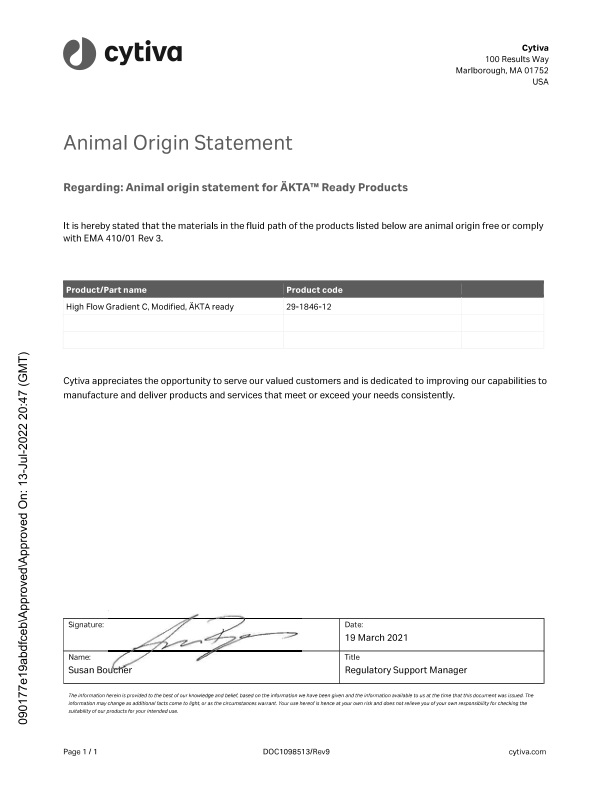

In [7]:
# Convert to grayscale (remove color)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

print("Grayscale version (color removed):")
display(Image.fromarray(gray))

After thresholding (high contrast):


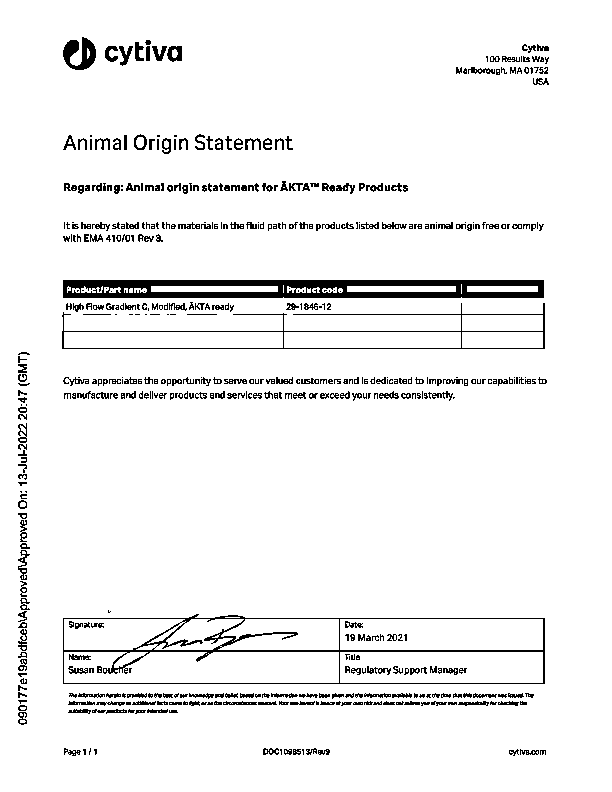

In [8]:
# Apply adaptive thresholding
# This automatically adjusts for different lighting in different areas
gray = cv2.adaptiveThreshold(
    gray,           # Input image
    255,            # Maximum value (white)
    cv2.ADAPTIVE_THRESH_MEAN_C,  # Method: use local mean
    cv2.THRESH_BINARY,           # Output: black or white only
    11,             # Block size (area to analyze)
    2               # Constant to subtract
)

print("After thresholding (high contrast):")
display(Image.fromarray(gray))

After noise reduction (cleaner):


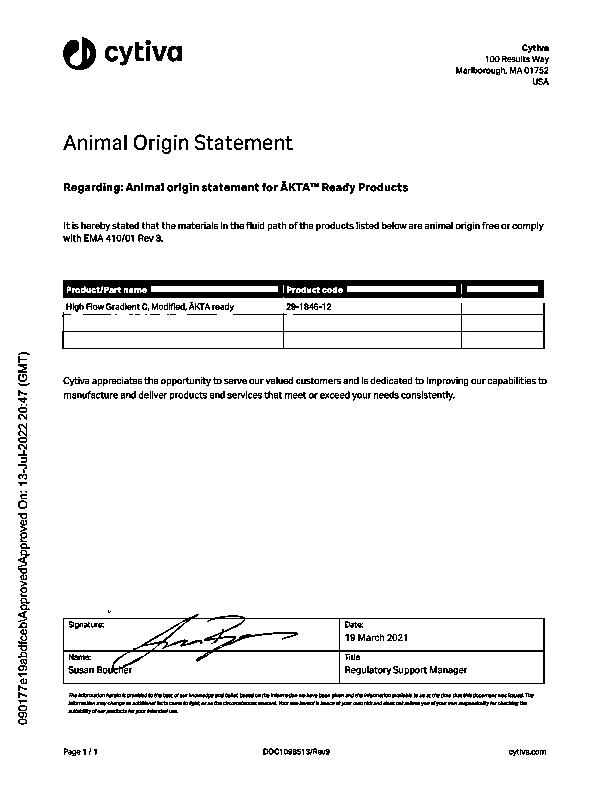

In [9]:
# Apply bilateral filtering
# This smooths the image while keeping edges (text) sharp
gray = cv2.bilateralFilter(
    gray,  # Input image
    9,     # Diameter of pixel neighborhood
    75,    # Filter sigma in the color space
    75     # Filter sigma in the coordinate space
)

print("After noise reduction (cleaner):")
display(Image.fromarray(gray))

Resized to 1224x1584 pixels (200% of original):


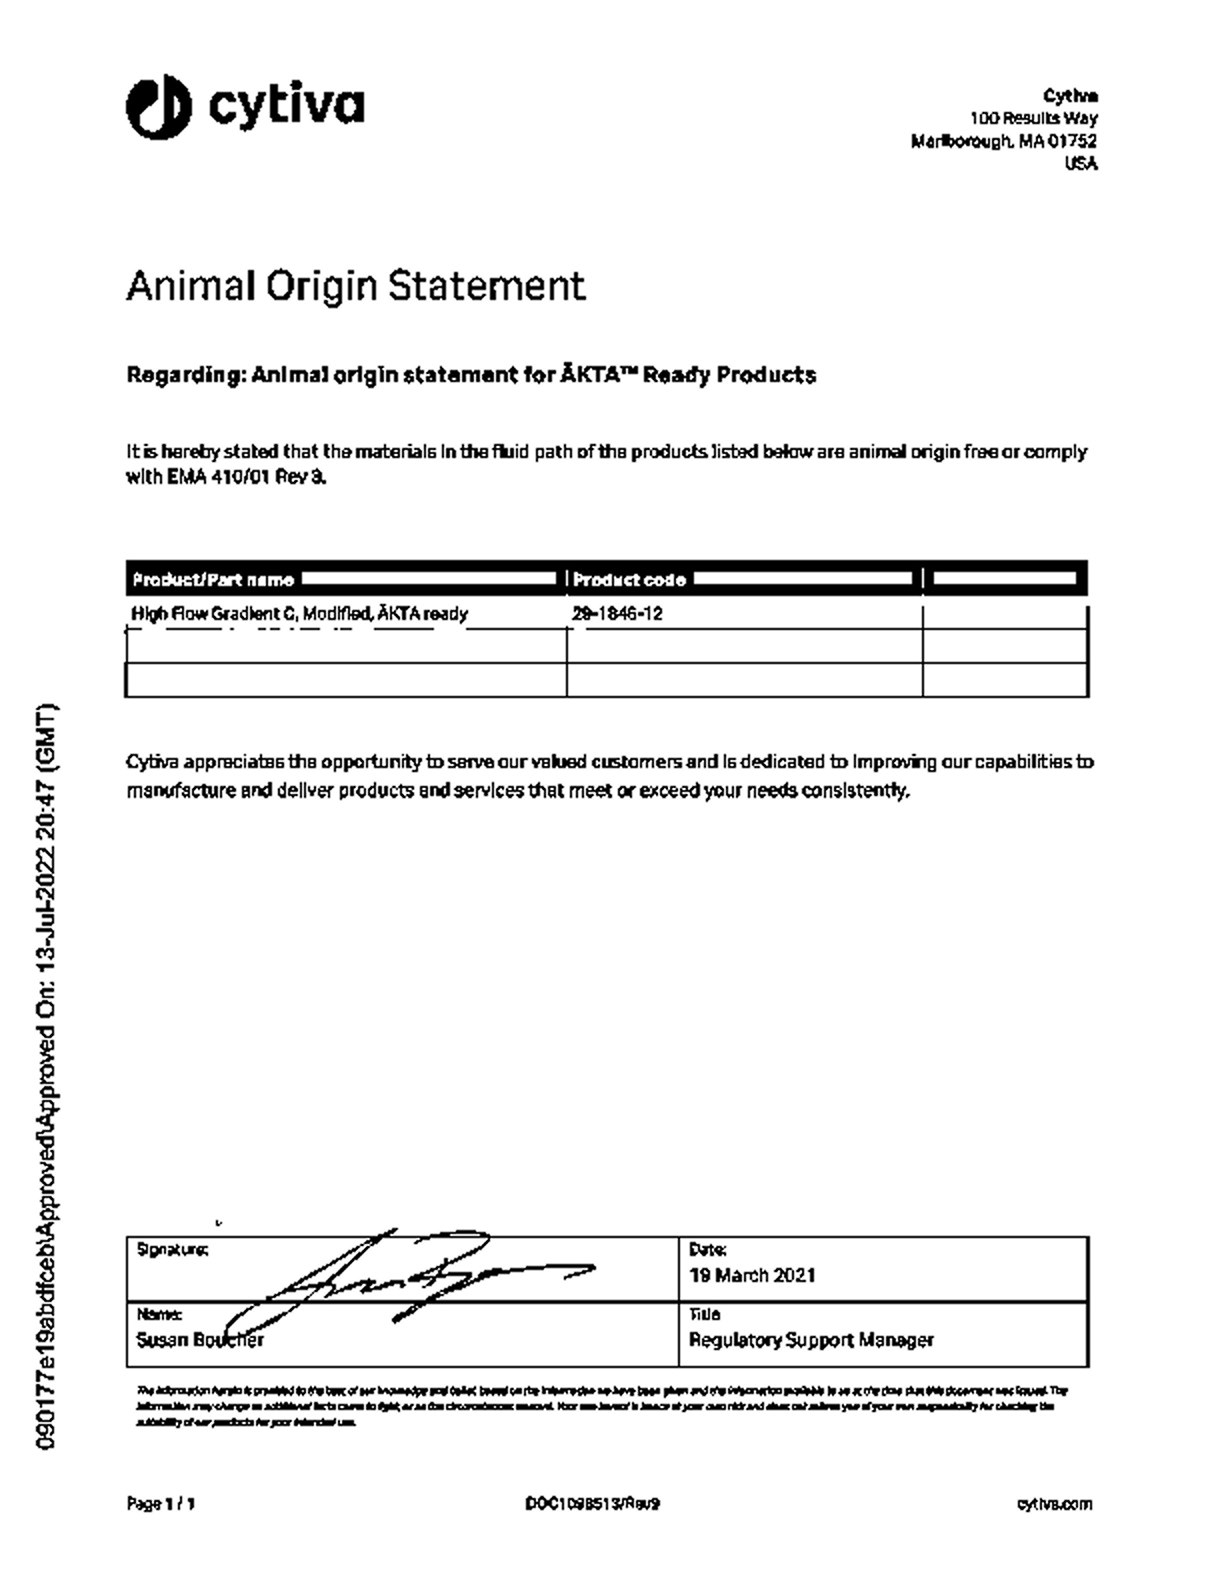

In [10]:
# Scale up the image by 200% (double the size)
scale_percent = 200
width = int(gray.shape[1] * scale_percent / 100)
height = int(gray.shape[0] * scale_percent / 100)

# Resize using high-quality interpolation
gray = cv2.resize(gray, (width, height), interpolation=cv2.INTER_CUBIC)

print(f"Resized to {width}x{height} pixels (200% of original):")
display(Image.fromarray(gray))

In [11]:
# Configure Tesseract for best results
# --oem 3: Use the neural network engine (most accurate)
# -l eng: Language is English
custom_config = r'--oem 3 -l eng'

# Run OCR!
ocr_text = pytesseract.image_to_string(gray, config=custom_config)

print("=" * 50)
print("OCR EXTRACTED TEXT")
print("=" * 50)
print(ocr_text)

OCR EXTRACTED TEXT
090177e19abdfceb\Approved\Approved On: 13-Juk-2022 20:47 (GMT)

2
¢) cytiva —_
Marlborough. MA 01752
USA

Animal Origin Statement

Regarding: Anima origin statamant for AKTA™ Ready Products

Itis hareby stated that the materials In the fluid path of the products listed below ara animal origin free ar comply
with EMA 410/01 Rev 2,

De I I
High Flow Gradent ©, Modified, AKTA ready 21846-12 |

 

Cytiva appreciates the opportunity to serve aur valued custamers and Is dedicated to Improving our capabilitias to
manufacture and deliver products and services that meet or exceed your needs cansistently,

 

 

Sipnkure, Date:
19 March 2021
Nese Tue
Susan B r Regulatory Support Manager

 

ss Leasheanallachambadalemasdabideskaherbes reasted aad enahiaaubalidiarthdambennded amLastlsh kbdesenpneunaen ubsdahdomdaabtabocethratpabicotied
Anbrrmun my charge mm action brts Care to fight ar a Com Cretan CAL Her mY RAC a yom cr AS ae cn? ren ye wr ran smepmaatcy Par cag
mitablity cf a

In [13]:
import re

# Step 11.1: Remove extra spaces and line breaks
ocr_text_clean = " ".join(ocr_text.split())

# Step 11.2: Fix common OCR errors in pharmaceutical documents
# These are words where OCR often mistakes numbers for letters
ocr_text_clean = re.sub(r'\bJuk\b', 'Jul', ocr_text_clean, flags=re.IGNORECASE)
# ocr_text_clean = re.sub(r'\bC0A\b', 'COA', ocr_text_clean, flags=re.IGNORECASE)

# Step 11.3: Remove any weird symbols that aren't useful
ocr_text_clean = re.sub(r'[^a-zA-Z0-9\s,.%-/:]', '', ocr_text_clean)

print("=" * 50)
print("CLEANED OCR TEXT")
print("=" * 50)
print(ocr_text_clean)

CLEANED OCR TEXT
090177e19abdfcebApprovedApproved On: 13-Jul-2022 20:47 (GMT) 2 ) cytiva  Marlborough. MA 01752 USA Animal Origin Statement Regarding: Anima origin statamant for AKTA Ready Products Itis hareby stated that the materials In the fluid path of the products listed below ara animal origin free ar comply with EMA 410/01 Rev 2, De I I High Flow Gradent , Modified, AKTA ready 21846-12  Cytiva appreciates the opportunity to serve aur valued custamers and Is dedicated to Improving our capabilitias to manufacture and deliver products and services that meet or exceed your needs cansistently, Sipnkure, Date: 19 March 2021 Nese Tue Susan B r Regulatory Support Manager ss Leasheanallachambadalemasdabideskaherbes reasted aad enahiaaubalidiarthdambennded amLastlsh kbdesenpneunaen ubsdahdomdaabtabocethratpabicotied Anbrrmun my charge mm action brts Care to fight ar a Com Cretan CAL Her mY RAC a yom cr AS ae cn ren ye wr ran smepmaatcy Par cag mitablity cf aar pecoct fr ocr ter Page 1/y B

In [15]:
# Get detailed OCR data including positions
ocr_data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)

# Show the first 20 detected words and their locations
print("Sample of detected words with bounding boxes:")
print("-" * 60)
count = 0
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    if word:  # Only show non-empty words
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]
        conf = ocr_data["conf"][i]
        print(f"Word: '{word}'  Position: ({x}, {y})  Size: {w}x{h}  Confidence: {conf}%")
        count += 1
        if count >= 20:
            break

print(f"\n...and {len([t for t in ocr_data['text'] if t.strip()])} total words detected!")

# TIP: The confidence score (0-100) tells you how sure Tesseract is.
# Scores below 40 are often mistakes!

Sample of detected words with bounding boxes:
------------------------------------------------------------
Word: '090177e19abdfceb\Approved\Approved'  Position: (36, 1026)  Size: 24x424  Confidence: 27%
Word: 'On:'  Position: (36, 982)  Size: 18x36  Confidence: 93%
Word: '13-Juk-2022'  Position: (36, 846)  Size: 18x126  Confidence: 39%
Word: '20:47'  Position: (36, 780)  Size: 18x60  Confidence: 95%
Word: '(GMT)'  Position: (36, 704)  Size: 24x68  Confidence: 95%
Word: '2'  Position: (290, 80)  Size: 12x10  Confidence: 77%
Word: '¢)'  Position: (126, 74)  Size: 66x66  Confidence: 23%
Word: 'cytiva'  Position: (210, 84)  Size: 154x48  Confidence: 91%
Word: '—_'  Position: (972, 88)  Size: 126x40  Confidence: 30%
Word: 'Marlborough.'  Position: (912, 134)  Size: 102x16  Confidence: 65%
Word: 'MA'  Position: (1020, 134)  Size: 24x14  Confidence: 25%
Word: '01752'  Position: (1048, 134)  Size: 48x14  Confidence: 25%
Word: 'USA'  Position: (1066, 156)  Size: 32x14  Confidence: 95%
Word: 'An

All detected words with bounding boxes (green):


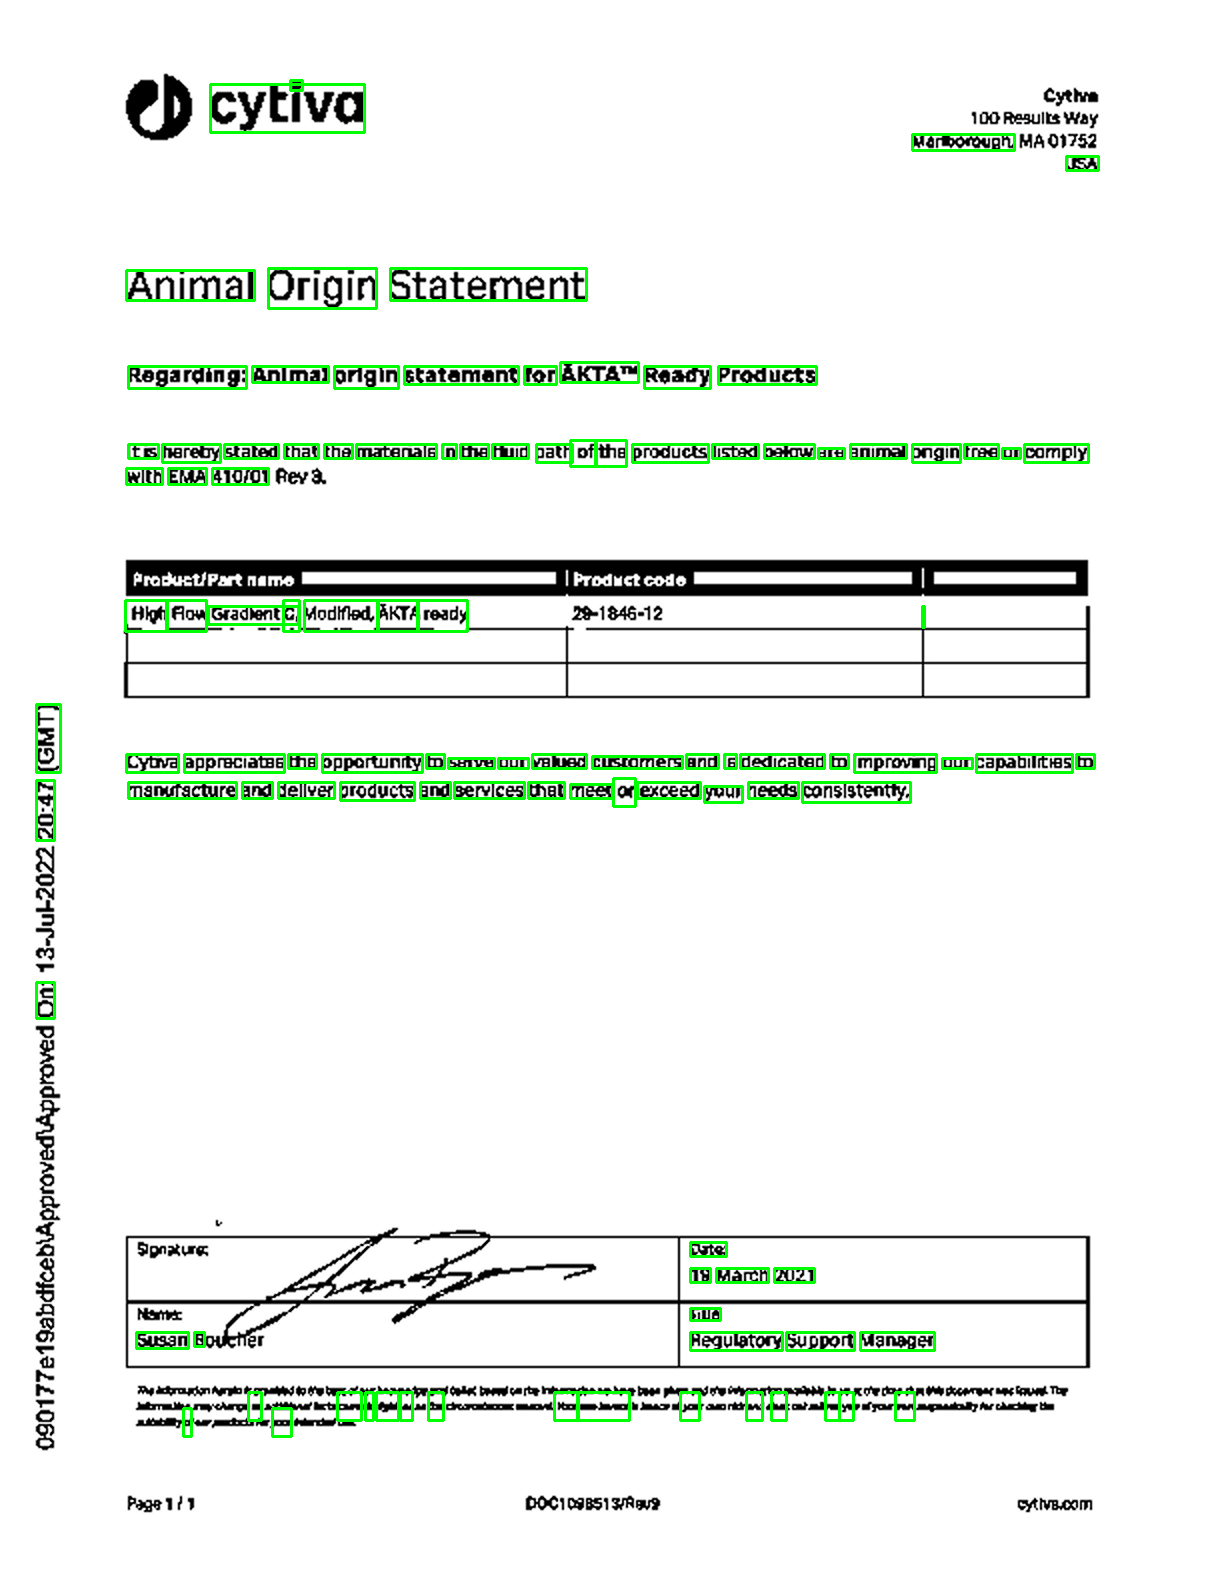

In [16]:
# Make a copy of the grayscale image (we'll draw on this)
# Convert to color so we can draw colored boxes
img_with_boxes = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)

# Set minimum confidence threshold (ignore low-confidence detections)
confidence_threshold = 40

# Loop through all detected words
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip()
    conf = int(ocr_data["conf"][i])

    # Skip empty words or low-confidence detections
    if not word or conf < confidence_threshold:
        continue

    # Get bounding box coordinates
    x = ocr_data["left"][i]
    y = ocr_data["top"][i]
    w = ocr_data["width"][i]
    h = ocr_data["height"][i]

    # Draw a green rectangle
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

print("All detected words with bounding boxes (green):")
# Convert BGR to RGB for display
display(Image.fromarray(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)))

# TIP: If you see boxes around noise/artifacts, increase confidence_threshold!

Found 8 key pharmaceutical terms:


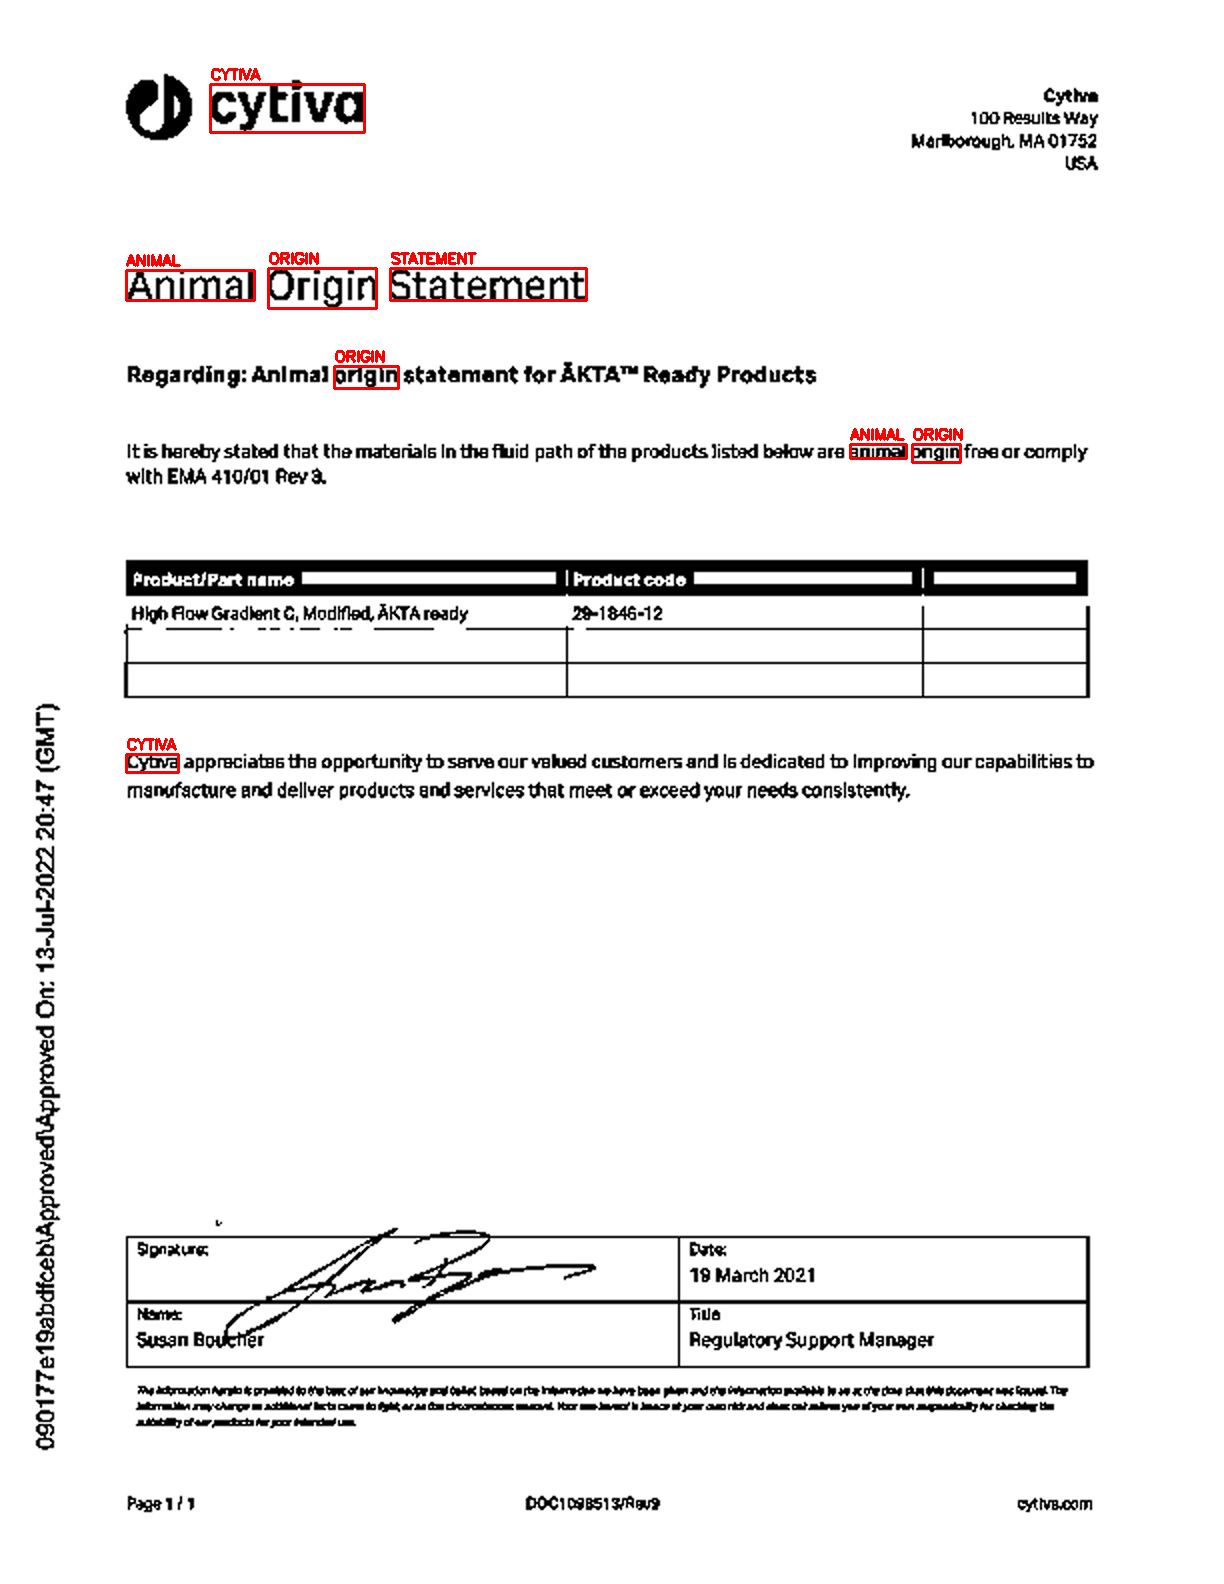

In [17]:

# Define the key fields we care about in pharmaceutical documents
key_fields = [
    "CYTIVA",
    "ANIMAL",
    "ORIGIN",
    "STATEMENT",
    "TITLE",
    "DATE",
    "NAME",
    "SIGNATURE",
    "PRODUCT"
]

# Create a fresh copy of the original image
img_key_fields = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)

# Loop through detected words and highlight only key fields
highlighted_count = 0
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip().upper()  # Convert to uppercase for matching

    # Check if this word is a key field
    if word in key_fields:
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]

        # Draw a RED rectangle and label
        cv2.rectangle(img_key_fields, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(img_key_fields, word, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        highlighted_count += 1

print(f"Found {highlighted_count} key pharmaceutical terms:")
display(Image.fromarray(cv2.cvtColor(img_key_fields, cv2.COLOR_BGR2RGB)))

# TIP: Add more terms to key_fields list if you want to highlight other words!

In [18]:
import json

# Create a dictionary to store our extracted data
extracted_data = {}

# Loop through and collect key fields
for i in range(len(ocr_data["text"])):
    word = ocr_data["text"][i].strip().upper()

    if word in key_fields:
        x = ocr_data["left"][i]
        y = ocr_data["top"][i]
        w = ocr_data["width"][i]
        h = ocr_data["height"][i]
        conf = ocr_data["conf"][i]

        extracted_data[word] = {
            "text": word,
            "bounding_box": [x, y, w, h],
            "confidence": conf
        }

# Convert to pretty JSON
json_output = json.dumps(extracted_data, indent=4)

print("=" * 50)
print("EXTRACTED KEY FIELDS (JSON FORMAT)")
print("=" * 50)
print(json_output)

# TIP: You can save this to a file with:
# with open("extracted_fields.json", "w") as f:
#     f.write(json_output)

EXTRACTED KEY FIELDS (JSON FORMAT)
{
    "CYTIVA": {
        "text": "CYTIVA",
        "bounding_box": [
            126,
            754,
            52,
            18
        ],
        "confidence": 82
    },
    "ANIMAL": {
        "text": "ANIMAL",
        "bounding_box": [
            850,
            444,
            56,
            14
        ],
        "confidence": 78
    },
    "ORIGIN": {
        "text": "ORIGIN",
        "bounding_box": [
            912,
            444,
            48,
            18
        ],
        "confidence": 96
    },
    "STATEMENT": {
        "text": "STATEMENT",
        "bounding_box": [
            390,
            268,
            196,
            32
        ],
        "confidence": 96
    }
}
